In [2]:
# =========================
# 1) Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

In [3]:
# =========================
# 2) Load data
# =========================
DATA_PATH = "/home/fyp_ids_e20/processed_dataset/balanced_network_data.csv"
df = pd.read_csv(DATA_PATH)

print("Loaded shape:", df.shape)
print(df["Label"].value_counts().head(20))

Loaded shape: (6870587, 23)
Label
Benign                      4122352
DDOS attack-HOIC             686012
DDoS attacks-LOIC-HTTP       576191
DoS attacks-Hulk             461912
Bot                          286191
FTP-BruteForce               193360
SSH-Bruteforce               187589
Infilteration                161934
DoS attacks-SlowHTTPTest     139890
DoS attacks-GoldenEye         41508
DoS attacks-Slowloris         10990
DDOS attack-LOIC-UDP           1730
Brute Force -Web                611
Brute Force -XSS                230
SQL Injection                    87
Name: count, dtype: int64


In [4]:
# =========================
# 3) Your feature list
# =========================
network_features = [
    "Dst Port",
    "Protocol",
    "Flow Duration",
    "Flow IAT Mean",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Max",
    "Fwd IAT Min",
    "Fwd IAT Tot",
    "Flow Pkts/s",
    "Fwd Pkts/s",
    "Bwd Pkts/s",
    "Tot Fwd Pkts",
    "Subflow Fwd Pkts",
    "Fwd Header Len",
    "Bwd Header Len",
    "Init Fwd Win Byts",
    "Init Bwd Win Byts",
    "PSH Flag Cnt",
    "RST Flag Cnt",
    "ACK Flag Cnt",
    "ECE Flag Cnt"
]

missing = [c for c in network_features if c not in df.columns]
if missing:
    print("WARNING: Missing features (skipping):", missing)

network_features = [c for c in network_features if c in df.columns]
print("Using", len(network_features), "features.")

Using 22 features.


In [5]:
# =========================
# 4) Clean data
# =========================
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["Label"]).copy()

y = df["Label"].astype(str).copy()
X = df[network_features].copy()

# force numeric
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

# drop rows with any NaN in selected features
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

print("After cleaning:", X.shape, y.shape)
print("Label counts (top 15):")
print(y.value_counts().head(15))

After cleaning: (6838750, 22) (6838750,)
Label counts (top 15):
Label
Benign                      4091816
DDOS attack-HOIC             686012
DDoS attacks-LOIC-HTTP       576191
DoS attacks-Hulk             461912
Bot                          286191
FTP-BruteForce               193354
SSH-Bruteforce               187589
Infilteration                160639
DoS attacks-SlowHTTPTest     139890
DoS attacks-GoldenEye         41508
DoS attacks-Slowloris         10990
DDOS attack-LOIC-UDP           1730
Brute Force -Web                611
Brute Force -XSS                230
SQL Injection                    87
Name: count, dtype: int64


In [6]:
# =========================
# 5) Split benign vs attacks
# =========================
X_benign = X[y == "Benign"]
X_attack = X[y != "Benign"]
y_attack_labels = y[y != "Benign"]

print("\nBenign samples:", len(X_benign))
print("Attack samples:", len(X_attack))
print("\nAttack distribution (top 15):")
print(y_attack_labels.value_counts().head(15))


Benign samples: 4091816
Attack samples: 2746934

Attack distribution (top 15):
Label
DDOS attack-HOIC            686012
DDoS attacks-LOIC-HTTP      576191
DoS attacks-Hulk            461912
Bot                         286191
FTP-BruteForce              193354
SSH-Bruteforce              187589
Infilteration               160639
DoS attacks-SlowHTTPTest    139890
DoS attacks-GoldenEye        41508
DoS attacks-Slowloris        10990
DDOS attack-LOIC-UDP          1730
Brute Force -Web               611
Brute Force -XSS               230
SQL Injection                   87
Name: count, dtype: int64


In [7]:
# =========================
# 6) Train/Val split on Benign (NO leakage)
# =========================
X_train_raw, X_val_raw = train_test_split(
    X_benign, test_size=0.2, random_state=42, shuffle=True
)

In [8]:
# =========================
# 7) Scale (fit on benign train only)
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_attack_scaled = scaler.transform(X_attack)

print("\nScaled shapes:")
print("Train:", X_train_scaled.shape, "Val:", X_val_scaled.shape, "Attack:", X_attack_scaled.shape)


Scaled shapes:
Train: (3273452, 22) Val: (818364, 22) Attack: (2746934, 22)


In [9]:
# =========================
# 8) Subsample benign training (One-Class SVM is slow)
# =========================
# You can increase this if your machine is strong.
MAX_TRAIN = 200000  # <-- tune this (50k-300k typical)
if X_train_scaled.shape[0] > MAX_TRAIN:
    rng = np.random.RandomState(42)
    idx = rng.choice(X_train_scaled.shape[0], size=MAX_TRAIN, replace=False)
    X_train_fit = X_train_scaled[idx]
    print(f"Subsampled benign train from {X_train_scaled.shape[0]} -> {X_train_fit.shape[0]}")
else:
    X_train_fit = X_train_scaled

Subsampled benign train from 3273452 -> 200000


#### nu = 0.05, gamma = scale

In [12]:
# =========================
# 9) Train One-Class SVM (fit on benign only)
# =========================
# nu ~ expected anomaly fraction in training data (benign should have small noise/outliers)
# gamma='scale' is safe default. For RBF kernel, gamma controls boundary complexity.
ocsvm = OneClassSVM(
    kernel="rbf",
    nu=0.05,       # try 0.01, 0.05, 0.1
    gamma="scale"  # or try gamma=0.1 / 0.01 / 1.0
)

ocsvm.fit(X_train_fit)
print("\nOne-Class SVM trained.")


One-Class SVM trained.


In [12]:
# =========================
# 10) Evaluate using .predict() (default decision boundary)
# =========================
# OneClassSVM predict:  1 = inlier (normal), -1 = outlier (anomaly)
pred_val = ocsvm.predict(X_val_scaled)
pred_attack = ocsvm.predict(X_attack_scaled)

y_val_true = np.zeros(len(pred_val), dtype=int)     # benign = 0
y_attack_true = np.ones(len(pred_attack), dtype=int) # attack = 1

y_val_pred = (pred_val == -1).astype(int)
y_attack_pred = (pred_attack == -1).astype(int)

y_true = np.concatenate([y_val_true, y_attack_true])
y_pred = np.concatenate([y_val_pred, y_attack_pred])

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
print("\nConfusion Matrix [[TN, FP],[FN, TP]]:\n", cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Benign", "Attack"]))


Confusion Matrix [[TN, FP],[FN, TP]]:
 [[ 777858   40506]
 [2170712  576222]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.26      0.95      0.41    818364
      Attack       0.93      0.21      0.34   2746934

    accuracy                           0.38   3565298
   macro avg       0.60      0.58      0.38   3565298
weighted avg       0.78      0.38      0.36   3565298



#### nu = 0.2, gamma = scale

In [ ]:
ocsvm = OneClassSVM(
    kernel="rbf",
    nu=0.2,     
    gamma="scale"  
)

ocsvm.fit(X_train_fit)
print("\nOne-Class SVM trained.")
print()

pred_val = ocsvm.predict(X_val_scaled)
pred_attack = ocsvm.predict(X_attack_scaled)

y_val_true = np.zeros(len(pred_val), dtype=int)     # benign = 0
y_attack_true = np.ones(len(pred_attack), dtype=int) # attack = 1

y_val_pred = (pred_val == -1).astype(int)
y_attack_pred = (pred_attack == -1).astype(int)

y_true = np.concatenate([y_val_true, y_attack_true])
y_pred = np.concatenate([y_val_pred, y_attack_pred])

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
print("\nConfusion Matrix [[TN, FP],[FN, TP]]:\n", cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Benign", "Attack"]))


One-Class SVM trained.


Confusion Matrix [[TN, FP],[FN, TP]]:
 [[ 653851  164513]
 [1314932 1432002]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.33      0.80      0.47    818364
      Attack       0.90      0.52      0.66   2746934

    accuracy                           0.59   3565298
   macro avg       0.61      0.66      0.56   3565298
weighted avg       0.77      0.59      0.62   3565298



#### nu = 0.3, gamma = scale

In [9]:
ocsvm = OneClassSVM(
    kernel="rbf",
    nu=0.3,    
    gamma="scale"
)

ocsvm.fit(X_train_fit)
print("\nOne-Class SVM trained.")
print()

pred_val = ocsvm.predict(X_val_scaled)
pred_attack = ocsvm.predict(X_attack_scaled)

y_val_true = np.zeros(len(pred_val), dtype=int)     # benign = 0
y_attack_true = np.ones(len(pred_attack), dtype=int) # attack = 1

y_val_pred = (pred_val == -1).astype(int)
y_attack_pred = (pred_attack == -1).astype(int)

y_true = np.concatenate([y_val_true, y_attack_true])
y_pred = np.concatenate([y_val_pred, y_attack_pred])

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
print("\nConfusion Matrix [[TN, FP],[FN, TP]]:\n", cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Benign", "Attack"]))


One-Class SVM trained.


Confusion Matrix [[TN, FP],[FN, TP]]:
 [[ 571726  246638]
 [1136058 1610876]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.33      0.70      0.45    818364
      Attack       0.87      0.59      0.70   2746934

    accuracy                           0.61   3565298
   macro avg       0.60      0.64      0.58   3565298
weighted avg       0.75      0.61      0.64   3565298



#### nu = 0.2, gamma = 0.1

In [10]:
ocsvm = OneClassSVM(
    kernel="rbf",
    nu=0.2,    
    gamma=0.1
)

ocsvm.fit(X_train_fit)
print("\nOne-Class SVM trained.")
print()

pred_val = ocsvm.predict(X_val_scaled)
pred_attack = ocsvm.predict(X_attack_scaled)

y_val_true = np.zeros(len(pred_val), dtype=int)     # benign = 0
y_attack_true = np.ones(len(pred_attack), dtype=int) # attack = 1

y_val_pred = (pred_val == -1).astype(int)
y_attack_pred = (pred_attack == -1).astype(int)

y_true = np.concatenate([y_val_true, y_attack_true])
y_pred = np.concatenate([y_val_pred, y_attack_pred])

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
print("\nConfusion Matrix [[TN, FP],[FN, TP]]:\n", cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Benign", "Attack"]))


One-Class SVM trained.


Confusion Matrix [[TN, FP],[FN, TP]]:
 [[ 653810  164554]
 [1006329 1740605]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.39      0.80      0.53    818364
      Attack       0.91      0.63      0.75   2746934

    accuracy                           0.67   3565298
   macro avg       0.65      0.72      0.64   3565298
weighted avg       0.79      0.67      0.70   3565298



#### nu = 0.3, gamma = 0.1

In [10]:
ocsvm = OneClassSVM(
    kernel="rbf",
    nu=0.3,    
    gamma=0.1
)

ocsvm.fit(X_train_fit)
print("\nOne-Class SVM trained.")
print()

pred_val = ocsvm.predict(X_val_scaled)
pred_attack = ocsvm.predict(X_attack_scaled)

y_val_true = np.zeros(len(pred_val), dtype=int)     # benign = 0
y_attack_true = np.ones(len(pred_attack), dtype=int) # attack = 1

y_val_pred = (pred_val == -1).astype(int)
y_attack_pred = (pred_attack == -1).astype(int)

y_true = np.concatenate([y_val_true, y_attack_true])
y_pred = np.concatenate([y_val_pred, y_attack_pred])

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
print("\nConfusion Matrix [[TN, FP],[FN, TP]]:\n", cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Benign", "Attack"]))


One-Class SVM trained.


Confusion Matrix [[TN, FP],[FN, TP]]:
 [[ 571620  246744]
 [ 990174 1756760]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.37      0.70      0.48    818364
      Attack       0.88      0.64      0.74   2746934

    accuracy                           0.65   3565298
   macro avg       0.62      0.67      0.61   3565298
weighted avg       0.76      0.65      0.68   3565298



#### nu = 0.4, gamma = 0.1

In [11]:
ocsvm = OneClassSVM(
    kernel="rbf",
    nu=0.4,    
    gamma=0.1
)

ocsvm.fit(X_train_fit)
print("\nOne-Class SVM trained.")
print()

pred_val = ocsvm.predict(X_val_scaled)
pred_attack = ocsvm.predict(X_attack_scaled)

y_val_true = np.zeros(len(pred_val), dtype=int)     # benign = 0
y_attack_true = np.ones(len(pred_attack), dtype=int) # attack = 1

y_val_pred = (pred_val == -1).astype(int)
y_attack_pred = (pred_attack == -1).astype(int)

y_true = np.concatenate([y_val_true, y_attack_true])
y_pred = np.concatenate([y_val_pred, y_attack_pred])

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
print("\nConfusion Matrix [[TN, FP],[FN, TP]]:\n", cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Benign", "Attack"]))


One-Class SVM trained.


Confusion Matrix [[TN, FP],[FN, TP]]:
 [[ 489632  328732]
 [ 600159 2146775]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.45      0.60      0.51    818364
      Attack       0.87      0.78      0.82   2746934

    accuracy                           0.74   3565298
   macro avg       0.66      0.69      0.67   3565298
weighted avg       0.77      0.74      0.75   3565298



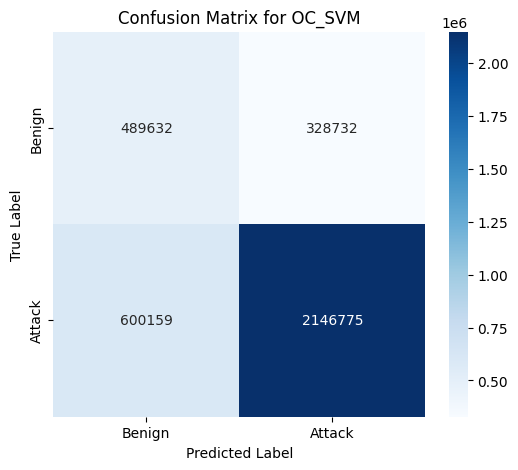

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = np.array(
     [[ 489632, 328732],
 [ 600159, 2146775]]
)

labels = ["Benign", "Attack"]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for OC_SVM")

plt.show()

In [13]:
# Tune threshold using benign validation scores
val_scores = -ocsvm.decision_function(X_val_scaled)        # anomaly score
attack_scores = -ocsvm.decision_function(X_attack_scaled)

for p in [90, 92, 95, 97, 99]:
    thr = np.percentile(val_scores, p)

    y_val_pred = (val_scores > thr).astype(int)
    y_attack_pred = (attack_scores > thr).astype(int)

    y_true = np.concatenate([np.zeros(len(y_val_pred)), np.ones(len(y_attack_pred))])
    y_pred = np.concatenate([y_val_pred, y_attack_pred])

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    attack_recall = tp / (tp + fn + 1e-12)
    benign_fpr = fp / (fp + tn + 1e-12)

    print(f"\nPercentile {p} | thr={thr:.6f} | FPR(Benign)={benign_fpr:.4f} | Recall(Attack)={attack_recall:.4f}")
    print(cm)


Percentile 90 | thr=-0.313210 | FPR(Benign)=0.1000 | Recall(Attack)=0.2122
[[ 736527   81837]
 [2163995  582939]]

Percentile 92 | thr=-0.085686 | FPR(Benign)=0.0800 | Recall(Attack)=0.2113
[[ 752894   65470]
 [2166387  580547]]

Percentile 95 | thr=-0.000744 | FPR(Benign)=0.0500 | Recall(Attack)=0.2098
[[ 777445   40919]
 [2170611  576323]]

Percentile 97 | thr=50.665832 | FPR(Benign)=0.0300 | Recall(Attack)=0.2079
[[ 793813   24551]
 [2175812  571122]]

Percentile 99 | thr=651.813707 | FPR(Benign)=0.0100 | Recall(Attack)=0.1730
[[ 810180    8184]
 [2271774  475160]]


In [ ]:
# =========================
# 11) ROC-AUC using decision_function scores
# =========================
# decision_function: higher = more normal. We'll invert so higher = more anomalous.
score_val = ocsvm.decision_function(X_val_scaled)
score_attack = ocsvm.decision_function(X_attack_scaled)

anomaly_score_val = -score_val
anomaly_score_attack = -score_attack

y_scores = np.concatenate([anomaly_score_val, anomaly_score_attack])
auc = roc_auc_score(y_true, y_scores)
print("ROC-AUC:", auc)

In [ ]:
# =========================
# 12) Per-attack detection rate (fraction flagged as anomaly)
# =========================
attack_labels = y_attack_labels.value_counts().index.tolist()

rows = []
for lab in attack_labels:
    X_lab = X[y == lab]
    X_lab_scaled = scaler.transform(X_lab)

    pred_lab = ocsvm.predict(X_lab_scaled)
    y_lab_pred = (pred_lab == -1).astype(int)

    detection_rate = y_lab_pred.mean()
    rows.append((lab, len(X_lab), detection_rate))

report_df = pd.DataFrame(rows, columns=["Attack Label", "Samples", "Detection Rate (flagged anomaly)"])
report_df = report_df.sort_values("Detection Rate (flagged anomaly)", ascending=False)

print("\nPer-attack detection rate (top 20):")
print(report_df.head(20))

report_df